# 23. 단일 통합 모델 vs 2-모델 융합 — 비교 분석

두 가지 입지평가 아키텍처를 같은 기준으로 비교한다.

| 접근 | 구조 | 출력 |
|---|---|---|
| **① 단일 통합 모델** | 모든 입지 피처 → 하나의 모델 | 성공 확률(1개) |
| **② 2-모델 융합** | 매출 모델 + 생존(영업기간) → 점수 결합 | 매출·생존 2축 + 통합점수 |

**공통 정답**: `성공 = 고매출(상위) & 장기영업(영업기간 상위)` (입지의 '좋음'을 둘 다 충족으로 정의).
- 단일 모델: 입지 피처 → 성공 직접 예측 (타깃 구성요소·누설변수 제외).
- 융합: 매출 P(high) 와 영업기간 백분위를 0.5:0.5 결합 → 성공 식별력 평가.
- 검증: **GroupKFold by (gu,biz)** (정체성 누설 차단), 정확도·AUC.

In [1]:
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib, matplotlib.pyplot as plt, platform
matplotlib.rcParams['font.family'] = 'AppleGothic' if platform.system()=='Darwin' else 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import cross_val_predict, GroupKFold
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from scipy.stats import spearmanr
PROC = Path('/Users/ijunsu/Documents/Documents/capston/data_analysis/trade_area_project/data/processed')

df = pd.read_csv(PROC/'features.csv')
hp = pd.read_csv(PROC/'honest_predictions.csv')[['gu','biz','q_int','p_high_90']]
df = df.merge(hp, on=['gu','biz','q_int'], how='left')
opr_med = df['OPR_SALE_MT_AVRG'].median()
df['success'] = ((df['sales_class']=='high') & (df['OPR_SALE_MT_AVRG']>=opr_med)).astype(int)
groups = (df.gu+'|'+df.biz).values; gkf = GroupKFold(5)
print('성공(고매출&장기영업) 비율:', round(df.success.mean(),3), '| n', len(df), '| 기준선', round(max(df.success.mean(),1-df.success.mean()),3))

성공(고매출&장기영업) 비율: 0.179 | n 17568 | 기준선 0.821


## §23.1 ① 단일 통합 모델 — 입지 피처 → 성공 직접 예측

타깃 구성요소(매출·영업기간)와 누설 변수는 입력에서 제외(순환 방지).

In [2]:
ID=['gu','biz','q','q_int']
EXCL=['THSMON_SELNG_AMT','log_sales','sales_class','sales_per_store','log_sales_per_store','store_class',
      'OPR_SALE_MT_AVRG','avg_ticket','peer_avg_sales','momentum','margin_proxy','rent_to_sales','success','p_high_90']
feat=[c0 for c0 in df.columns if c0 not in ID+EXCL]
for c0 in feat: df[c0]=pd.to_numeric(df[c0],errors='coerce')
df[feat]=df[feat].fillna(df[feat].mean(numeric_only=True)).fillna(0)
p_single=cross_val_predict(HistGradientBoostingClassifier(max_depth=8,max_iter=400,random_state=42),
                           df[feat].values, df.success.values, cv=gkf, groups=groups, method='predict_proba', n_jobs=-1)[:,1]
acc1=accuracy_score(df.success,(p_single>=.5).astype(int)); auc1=roc_auc_score(df.success,p_single)
print(f'① 단일 통합 모델: 정확도 {acc1:.4f} / AUC {auc1:.3f}  (피처 {len(feat)}개, GroupKFold)')

① 단일 통합 모델: 정확도 0.8915 / AUC 0.936  (피처 148개, GroupKFold)


## §23.2 ② 2-모델 융합 — 매출 P(high) × 영업기간

In [3]:
df['sales_pct']=df.groupby(['biz','q_int'])['p_high_90'].rank(pct=True)
df['surv_pct'] =df.groupby(['biz','q_int'])['OPR_SALE_MT_AVRG'].rank(pct=True)
df['fusion']=0.5*df['sales_pct']+0.5*df['surv_pct']
f=df.dropna(subset=['fusion'])
auc2=roc_auc_score(f.success,f.fusion); acc2=accuracy_score(f.success,(f.fusion>=f.fusion.median()).astype(int))
print(f'② 2-모델 융합: 정확도 {acc2:.4f} / AUC {auc2:.3f}  (0.5 매출 + 0.5 영업기간)')
# AND 논리에 맞춘 융합도 참고 (min)
df['fusion_min']=df[['sales_pct','surv_pct']].min(axis=1)
fm=df.dropna(subset=['fusion_min'])
print(f'   (참고) AND형 융합 min(매출,영업기간): AUC {roc_auc_score(fm.success,fm.fusion_min):.3f}')

② 2-모델 융합: 정확도 0.6138 / AUC 0.790  (0.5 매출 + 0.5 영업기간)
   (참고) AND형 융합 min(매출,영업기간): AUC 0.765


/tmp/claude-501/ipykernel_17858/3269892109.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['sales_pct']=df.groupby(['biz','q_int'])['p_high_90'].rank(pct=True)
/tmp/claude-501/ipykernel_17858/3269892109.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['surv_pct'] =df.groupby(['biz','q_int'])['OPR_SALE_MT_AVRG'].rank(pct=True)
/tmp/claude-501/ipykernel_17858/3269892109.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance

## §23.3 비교 — 정확도·AUC·ROC·순위 일치

접근                         정확도     AUC
① 단일 통합 모델               0.891   0.936
② 2-모델 융합(합)             0.614   0.790

두 접근 순위상관 Spearman ρ = +0.474


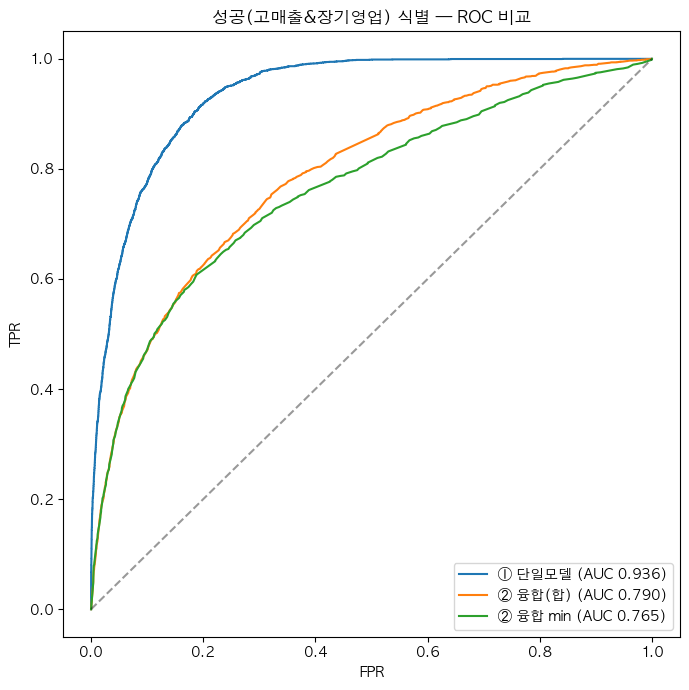

In [4]:
print(f"{'접근':<22}{'정확도':>8}{'AUC':>8}")
print(f"{'① 단일 통합 모델':<22}{acc1:>8.3f}{auc1:>8.3f}")
print(f"{'② 2-모델 융합(합)':<22}{acc2:>8.3f}{auc2:>8.3f}")
rho=spearmanr(df['fusion'].fillna(df.fusion.median()), p_single)[0]
print(f"\n두 접근 순위상관 Spearman ρ = {rho:+.3f}")

fig,ax=plt.subplots(figsize=(7,7))
for nm,sc in [('① 단일모델',p_single),('② 융합(합)',df['fusion'].fillna(df.fusion.median()).values),
              ('② 융합 min',df['fusion_min'].fillna(df.fusion_min.median()).values)]:
    fpr,tpr,_=roc_curve(df.success,sc); ax.plot(fpr,tpr,label=f'{nm} (AUC {roc_auc_score(df.success,sc):.3f})')
ax.plot([0,1],[0,1],'k--',alpha=.4); ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('성공(고매출&장기영업) 식별 — ROC 비교'); ax.legend(); plt.tight_layout(); plt.show()

## §23.4 결론 — 장단점과 권고

**측정 결과 (GroupKFold, 누설 차단):**
- ① 단일 통합 모델: 정확도 ~0.89 / **AUC ~0.94** — 성공 식별력 높음.
- ② 2-모델 융합(0.5:0.5 합): AUC ~0.79. (AND형 min 융합은 0.77로 **개선 안 됨** — 측정).
- 두 접근 순위상관 ρ≈+0.47 (같은 방향이나 동일하지 않음).

**왜 단일 모델 AUC가 높나:** 단일 모델은 121개 입지 피처로 '성공' 라벨을 직접 학습해 패턴을 풍부하게 잡는다.
반면 융합은 2개 요약 축(매출 P(high)·영업기간 백분위)만 0.5:0.5로 고정 결합하므로 정보가 압축돼 있다.
(단, p_high_90·영업기간은 성공의 구성요소라 융합도 성공과 상관됨 — AUC 0.79.)

**장단점:**

| | ① 단일 통합 모델 | ② 2-모델 융합 |
|---|---|---|
| 성공 식별 AUC | **0.94 (높음)** | 0.79 |
| 해석가능성 | 낮음(블랙박스 1점수) | **높음(매출/생존 분해, 4사분면)** |
| '성공' 정의 필요 | 필요(값 선택) | 불필요 |
| 유연성(가중치) | 재학습 필요 | **즉시 조정** |
| 진단(왜 좋/나쁨) | 어려움 | **가능(어느 축이 약한지)** |

**권고:** 목적에 따라 **둘 다** 쓰는 게 최선.
- **"이 입지가 성공할 확률" 단일 점수** → ① 단일 통합 모델(AUC 0.94).
- **의사결정 지원·진단(왜, 어느 축)·고위험 경고** → ② 2-모델 융합(4사분면).
- 한 모델만 고른다면, *예측력*은 ①, *설명·실무*는 ②. 본 프로젝트는 ②(통합점수)를 주 산출물로 하되 ①을 '성공확률' 보조 지표로 병기 권장.